# Warm Up: BrainHack Assignment Part... Before We Go on a Rollercoaster Ride
Yours should look like this too 👀 <br><br>
> ⚠️ <strong>DISCLAIMER</strong><br> Just like you (and these models/machines 🤖), I am learing too. While I try my best to provide accurate information to the best of my knowledge, algorithms and model architecture can be complex, abstract, not to mention that data sciene and AI-adjacent fields are themselves rapidly evolving. If there's anything that can be better explained or if I've made any mistakes, please do let me know. That's how models learn after all -- by minimizing error. My DMs are always open 📨


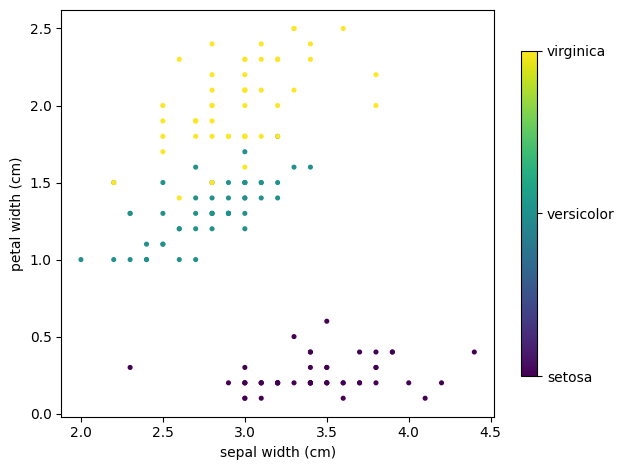

In [ ]:
import sklearn
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
iris = load_iris()

# the indices of the features that we are plotting
x_index = 1
y_index = 3

# this formatter will label the colorbar with the correct target names
formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)])

plt.scatter(iris.data[:, x_index], iris.data[:, y_index],
            s=7, c=iris.target) # c=iris.target gets mapped to the right color by FuncFormatter
plt.colorbar(format=formatter, ticks=[0, 1, 2], shrink=0.8)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])

plt.tight_layout()
plt.show()

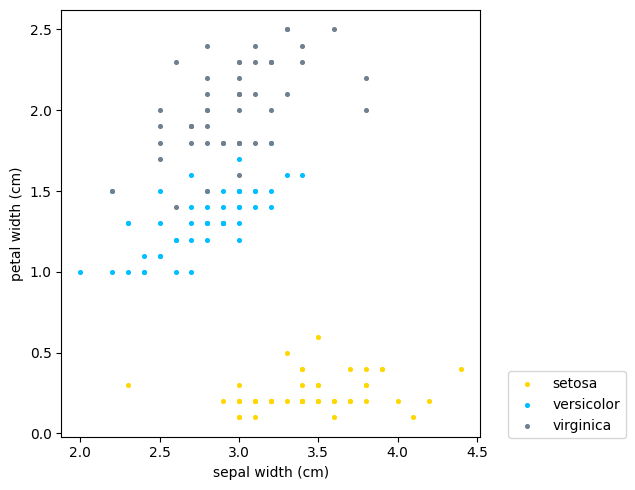

In [ ]:
# discrete colors is probably more suitable than a continuous colorbar for n_class=3
colors = ["gold", "deepskyblue", "slategrey"]

plt.figure(figsize=(6.5, 5))
for i, color in enumerate(colors):
    mask = iris.target == i
    plt.scatter(
        iris.data[mask, x_index],
        iris.data[mask, y_index],
        c=color,
        label=iris.target_names[i],
        s=7
    )

plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])
plt.legend(bbox_to_anchor=(1.05, 0.17))
plt.tight_layout()
plt.show()

In [ ]:
X, y = iris.data, iris.target
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

# What kind of iris has 3cm x 5cm sepal and 4cm x 32cm petal?
print(f"What kind of iris has 3cm x 5cm sepal and 4cm x 32cm petal?\n>> Model prediction: {iris.target_names[knn.predict([[3, 5, 4, 2]])][0]}")

What kind of iris has 3cm x 5cm sepal and 4cm x 32cm petal?
>> Model prediction: virginica


/tmp/ipykernel_92615/3302167678.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 0.17))


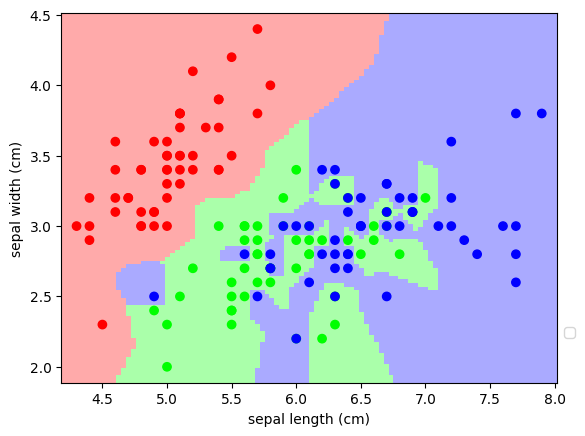

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import neighbors, datasets
from matplotlib.colors import ListedColormap

# Create color maps for 3-class classification problem, as with iris
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features. We could
                    # avoid this ugly slicing by using a two-dim dataset # 💡 or use dimensionality reduction, like pca or t-sne (for VISUALIZATION ONLY, not the classification itself)
y = iris.target

knn = neighbors.KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),

                        np.linspace(y_min, y_max, 100)) # note what your doing here is: train on iris, then predict on meshgrid points (more fine-grained)
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.axis('tight')
plt.show()

# KNN with Hyperparamerter Tuning (selecting best K) via Cross-Validation
Your code thus far is 👌, but it's not yet a complete machine learning pipeline. Below I demonstrate this using larger datasets —— `load_breast_cancer()` and `load_digits()` ——  first with _manual_ implementation of the k-fold loop with a proper _scaling_ transformation $_{[1]}$, then following the standard `sklearn.pipeline` workflow.<br><br>
<small>[1] Note that scaling (via `StandardScaler`) is needed since sometimes raw data's features might come in different scales (though this is not the case with the Iris dataset since all features are in centimeters), and the model could get dominated by features on larger scales. </small>
<br><br>
### 0. Crash Course
`train_test_split` (done twice)
- **Training set $D_{train}$**
  - where the model learns
- **Validation set $D_{valid}$**
  - best "setting" selection, used repeatedly
  - _hyperparameter tuning_
- **Test set $D_{test}$**
  - final exam, used once at the end

`cross_val_score`
- Define a range of K values (K is a _hyperparamer_).
- Define a fold number $k$ (most commonly $k = 10$).
- For each hyperparameter value K, split $D_{train} ∪ D_{valid}$ into $k$ folds; in each run, one of the folds serves as the _held-out validation set_, and the remaining $k-1$ folds are used for training. Repeat this process $k$ times such that each fold is the held-out set exactly once. Average the evaluation score (e.g., accuracy) over the $k$ folds.
- The optimal K is the value that yields the highest averaged $k$-fold evaluation score.

Finally, retrain the model with the optimal K on $D_{train} ∪ D_{valid}$, then evaluate on $D_{test}$.<br><br>

### 1. Manual Implementation

In [ ]:
from sklearn.datasets import load_breast_cancer, load_digits, load_iris
cancer, digits = load_breast_cancer(), load_digits()
s = "\n   "
print(f"BREAST CANCER DATASET{s}- (num_samples, num_features) = {cancer.data.shape}{s}- Number of classes = {len(set(cancer.target))}".format(s))
print(f"\nDIGITS DATASET{s}- (num_samples, num_features) = {digits.data.shape}{s}- Number of classes = {len(set(digits.target))}".format(s))

BREAST CANCER DATASET
   - (num_samples, num_features) = (569, 30)
   - Number of classes = 2

DIGITS DATASET
   - (num_samples, num_features) = (1797, 64)
   - Number of classes = 10


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from collections import namedtuple
from IPython.display import clear_output

RANDOM_STATE = 47
WEIGHTS = "distance"  # neighbors weighed by inverse distance (default is "uniform")
ALGORITHM = "auto" # algorithm used in knn to find the nearest neighbors
LEAF_SIZE = 30
P = 2
METRIC = "minkowski" # standard L2 norm
METRIC_PARAMS = None


CrossValidated = namedtuple("CrossValidated", ["X_train", "y_train", "X_test", "y_test", "k"])

# cursed way to do it using class inheritance lol <- don't use it in sklearn practice; but can learn OOP from it
class _KNN_(KNeighborsClassifier):
   def __init__(self, n_neighbors, weights="uniform",
                                   algorithm="auto",
                                   leaf_size=30,
                                   p=2,
                                   metric="minkowski",
                                   metric_params=None):
      super().__init__(
            n_neighbors,
            weights=weights,
            algorithm=algorithm,
            leaf_size=leaf_size,
            p=p,
            metric=metric,
            metric_params=metric_params,
            )
   def fit(self, X, y):
      scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
      scaler.fit(X)
      X = scaler.transform(X)
      self.scaler = scaler
      super().fit(X, y)
      return self
   def score(self, X, y):
      X = self.scaler.transform(X)
      return super().score(X, y)


def custom_knn_with_cv(krange: list, X: np.array, y: np.array,
                              test_frac: float=0.1, n_splits: int=10, clear_cv_output=False,
                              epsilon=1e-5) -> namedtuple:

    def for_each_k(k, skf, folds, X_train_valid, y_train_valid):
        valid_accuracy = 0
        for i, (train_index, valid_index) in enumerate(folds):
            print(f"   FOLD {i+1}:")
            X_train, X_valid = X_train_valid[train_index], X_train_valid[valid_index]
            y_train, y_valid = y_train_valid[train_index], y_train_valid[valid_index]
            scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
            scaler.fit(X_train)  # important: scaler only fits to training data in each fold to prevent data leakage in to validation
            X_train = scaler.transform(X_train)
            X_valid = scaler.transform(X_valid)

            knn = KNeighborsClassifier(k,
                                      weights=WEIGHTS,
                                      algorithm=ALGORITHM,
                                      leaf_size=LEAF_SIZE,
                                      p=P,
                                      metric=METRIC,
                                      metric_params=METRIC_PARAMS)
            knn.fit(X_train, y_train)
            print(f"        Train accuracy: {round(knn.score(X_train, y_train), 4)}") # should usually be very high for small datasets like these
            valid_accuracy += knn.score(X_valid, y_valid)
            print(f"        Valid accuracy: {round(knn.score(X_valid, y_valid), 4)}")

        mean_valid_accuracy = valid_accuracy / n_splits
        print(f"   >> Mean valid accuracy: {round(mean_valid_accuracy, 4)}\n")

        # this part uses cross_val_score (to validate my manual implementation)
        _knn_ = _KNN_(k,
                      weights=WEIGHTS,
                      algorithm=ALGORITHM,
                      leaf_size=LEAF_SIZE,
                      p=P,
                      metric=METRIC,
                      metric_params=METRIC_PARAMS)
        _cvs_ = cross_val_score(_knn_,
                              X_train_valid,
                              y_train_valid,
                              scoring = None, # use _knn_.score()
                              cv = skf)
        _mean_cvs_ = np.mean(_cvs_)

        if abs(mean_valid_accuracy - _mean_cvs_) > epsilon:
            raise Exception("Manual implementation and cross_val_scores don't match!")

        return mean_valid_accuracy

    X_train_valid, X_test, y_train_valid, y_test= train_test_split(X, y,
                                            random_state=RANDOM_STATE,
                                            test_size=test_frac,
                                            shuffle=True,
                                            stratify=y)
    assert (X_train_valid.shape[0] + X_test.shape[0]) == X.shape[0]
    assert (y_train_valid.shape[0] + y_test.shape[0]) == y.shape[0]

    skf = StratifiedKFold(n_splits=n_splits,
                         random_state=RANDOM_STATE,
                         shuffle=True)
    folds = list(skf.split(X_train_valid, y_train_valid))

    accuracies = np.empty(len(krange))
    for i, k in enumerate(krange):
        print(f"K = {k}")
        mean_valid_accuracy = for_each_k(k, skf, folds, X_train_valid, y_train_valid)
        accuracies[i] = mean_valid_accuracy

    idx = np.argmax(accuracies)
    best_k = krange[idx]
    if clear_cv_output:
        clear_output()
    print(f"\nBEST K = {best_k}\nACCURACY = {round(accuracies[idx], 4)}\n")

    cv = CrossValidated(X_train_valid, y_train_valid, X_test, y_test, best_k)
    return cv

def final_model(cv: CrossValidated) -> KNeighborsClassifier:
    scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
    X_train, y_train, X_test, y_test, k = cv.X_train, cv.y_train, cv.X_test, cv.y_test, cv.k
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)

    knn = KNeighborsClassifier(k,
                              weights=WEIGHTS,
                              algorithm=ALGORITHM,
                              leaf_size=LEAF_SIZE,
                              p=P,
                              metric=METRIC,
                              metric_params=METRIC_PARAMS)
    knn.fit(X_train, y_train)
    print("FINAL MODEL EVAL:")
    print(f"   Train accuracy: {round(knn.score(X_train, y_train), 4)}") # should usually be very high for small datasets like these
    print(f"   Test accuracy: {round(knn.score(X_test, y_test), 4)}")
    return knn, scaler

In [ ]:
X_cancer, y_cancer = cancer.data, cancer.target
X_digits, y_digits = digits.data, digits.target

krange = list(range(1, 11))

cv_cancer = custom_knn_with_cv(krange, X_cancer, y_cancer, clear_cv_output=True)
cancer_knn, cancer_scaler = final_model(cv_cancer)
print("\n--- Cancer Dataset --- ")


BEST K = 9
ACCURACY = 0.9667

FINAL MODEL EVAL:
   Train accuracy: 1.0
   Test accuracy: 1.0

--- Cancer Dataset --- 


In [ ]:
cv_digits = custom_knn_with_cv(krange, X_digits, y_digits, clear_cv_output=True)
digits_knn, digits_scaler = final_model(cv_digits)
print("\n--- Digits Dataset --- ")


BEST K = 5
ACCURACY = 0.9771

FINAL MODEL EVAL:
   Train accuracy: 1.0
   Test accuracy: 0.9833

--- Digits Dataset --- 


### 2. `Sklearn` Pipeline
- The manual implementation above was just me enjoying self-abuse.
- _This_ is the standard pipeline (pun intended)



In [ ]:
from sklearn.pipeline import Pipeline

def knn_with_cv(krange: list, X: np.array, y: np.array,
                test_frac: float=0.1, n_splits: int=10, display_res=False):
    def for_each_k(k, skf, X_train, y_train):
        scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
        knn = KNeighborsClassifier(k,
                                  weights=WEIGHTS,
                                  algorithm=ALGORITHM,
                                  leaf_size=LEAF_SIZE,
                                  p=P,
                                  metric=METRIC,
                                  metric_params=METRIC_PARAMS)
        pipeline = Pipeline(steps=[("scaler", scaler), ("knn", knn)])
        cvs = cross_val_score(pipeline,
                                X_train,
                                y_train,
                                scoring = None, # use pipeline.score()
                                cv = skf)
        return np.mean(cvs)

    X_train, X_test, y_train, y_test= train_test_split(X, y,
                                            random_state=RANDOM_STATE,
                                            test_size=test_frac,
                                            shuffle=True,
                                            stratify=y)
    assert (X_train.shape[0] + X_test.shape[0]) == X.shape[0]
    assert (y_train.shape[0] + y_test.shape[0]) == y.shape[0]

    skf = StratifiedKFold(n_splits=n_splits,
                         random_state=RANDOM_STATE,
                         shuffle=True)

    accuracies = np.empty(len(krange))
    for i, k in enumerate(krange):
        mean_valid_accuracy = for_each_k(k, skf, X_train, y_train)
        accuracies[i] = mean_valid_accuracy

    idx = np.argmax(accuracies)
    best_k = krange[idx]
    if display_res:
        print(f"BEST K = {best_k}\nACCURACY = {round(accuracies[idx], 4)}")

    scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
    knn = KNeighborsClassifier(best_k,
                              weights=WEIGHTS,
                              algorithm=ALGORITHM,
                              leaf_size=LEAF_SIZE,
                              p=P,
                              metric=METRIC,
                              metric_params=METRIC_PARAMS)
    pipeline = Pipeline(steps=[("scaler", scaler), ("knn", knn)])
    pipeline.fit(X_train, y_train)
    if display_res:
        print("========================")
        print("FINAL MODEL EVAL:")
        print(f"   Train accuracy: {round(pipeline.score(X_train, y_train), 4)}") # should usually be very high for small datasets like these
        print(f"   Test accuracy: {round(pipeline.score(X_test, y_test), 4)}")
    return pipeline

In [ ]:
print("**Cancer Dataset**")
_ = knn_with_cv(krange, X_cancer, y_cancer, display_res=True)
print("\n\n**Digits Dataset**")
_ = knn_with_cv(krange, X_digits, y_digits, display_res=True)
print("\n")
display(_)

**Cancer Dataset**
BEST K = 9
ACCURACY = 0.9667
FINAL MODEL EVAL:
   Train accuracy: 1.0
   Test accuracy: 1.0


**Digits Dataset**
BEST K = 5
ACCURACY = 0.9771
FINAL MODEL EVAL:
   Train accuracy: 1.0
   Test accuracy: 0.9833




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30

### 3. ❓Question for whoever's reading this:
- Read up on _K-means clistering_ online (or ask an LLM).
- What's the difference between KNN and K-means clustering?
- The code below uses _PCA (pricipal component analysis)_ to reduce the data dimension down to 2 for visualization.

Please note that K-means clustering labels and original ground truth labels do not necessarily match in the 'same number, same class'
sense as cluster IDs are arbitrary. To evaluate 'clustering accuracy', we could do post-hoc cluster ID to ground truth mapping that maximizes
agreement. For example, we can permute the cluster IDs and, for each permutation, construct the confusion matrix, and find the permutation
such that the trace (sum of diagonal) of the matrix is maximized. For larger datasets, we implement other algorithms instead of brute-forcing
over all the permutations.




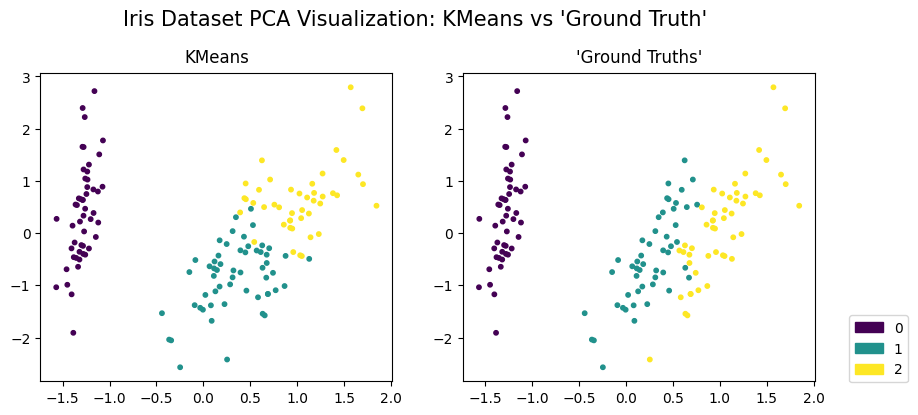

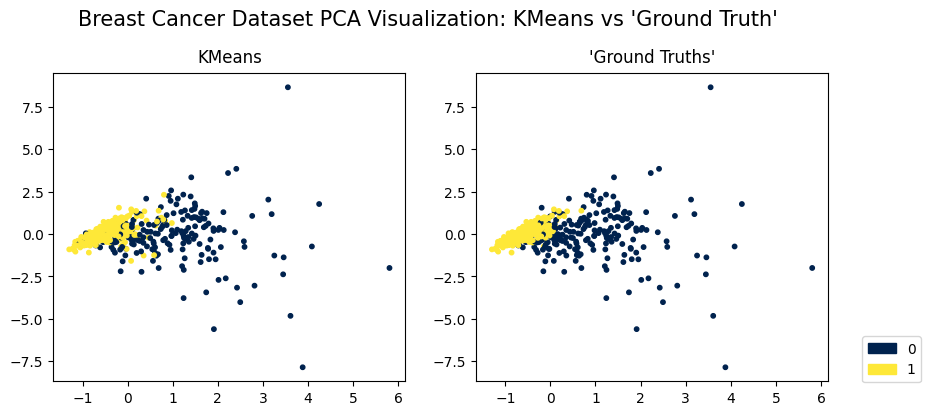

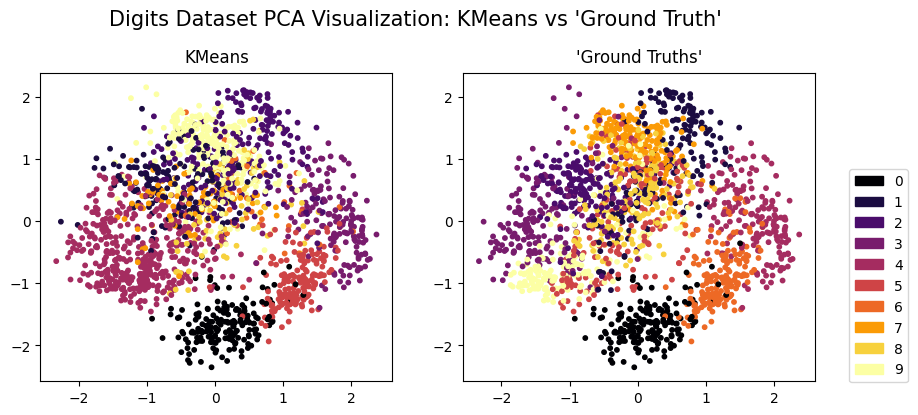

In [ ]:
from sklearn.cluster import KMeans
from sklearn.utils import Bunch
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

def compare_with_kmeans(bunch: Bunch, **kwargs) -> np.array:
    X, y = bunch.data, bunch.target
    n_clusters = len(set(y))

    scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
    scaler.fit(X)
    X = scaler.transform(X)

    params = kwargs.copy()
    try:
        params.pop("dataset")
        params.pop("colorname")
    except KeyError:
        pass

    km = KMeans(n_clusters=n_clusters,
                random_state=RANDOM_STATE,
                copy_x=True,
                **params
                )
    km.fit(X)
    labels = km.labels_

    def plot_kmeans():
        pca = PCA(n_components=2,
                  whiten=True,
                  svd_solver="auto",
                  random_state=RANDOM_STATE)
        X = pca.fit_transform(bunch.data)

        uid = set(labels)
        colorname = kwargs.get("colorname", "inferno")
        cmap = plt.get_cmap(colorname, len(uid))
        colors_map = {u: cmap(i) for i, u in enumerate(uid)}
        colors0 = [colors_map[i] for i in labels]
        colors1 = [colors_map[i] for i in y]

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        scatter0 = axes[0].scatter(X[:,0], X[:,1], c=colors0, s=10)
        scatter1 = axes[1].scatter(X[:,0], X[:,1], c=colors1, s=10)
        axes[0].set_title("KMeans", y=1.01)
        axes[1].set_title("'Ground Truths'", y=1.01)

        handles = [mpatches.Patch(color=list(colors_map.values())[i], label=list(colors_map.keys())[i])
           for i in range(len(colors_map))]
        fig.legend(handles=handles,
                  loc="lower right",
                  bbox_to_anchor=(1.0, 0.09))

        fig.suptitle(f"{kwargs.get("dataset", "")} Dataset PCA Visualization: KMeans vs 'Ground Truth'",
                     fontsize = 15, y=1.04)
        plt.show()

    plot_kmeans()
    return labels

print(f"""Please note that K-means clustering labels and original ground truth labels do not necessarily match in the 'same number, same class'
sense as cluster IDs are arbitrary. To evaluate 'clustering accuracy', we could do post-hoc cluster ID to ground truth mapping that maximizes
agreement. For example, we can permute the cluster IDs and, for each permutation, construct the confusion matrix, and find the permutation
such that the trace (sum of diagonal) of the matrix is maximized. For larger datasets, we implement other algorithms instead of brute-forcing
over all the permutations.\n\n""")

km_labels_iris = compare_with_kmeans(iris, dataset="Iris", colorname="viridis",
                                     algorithm="elkan")
print("\n\n")
km_labels_cancer = compare_with_kmeans(cancer, dataset="Breast Cancer", colorname="cividis")
print("\n\n")
km_labels_digits = compare_with_kmeans(digits, dataset="Digits",
                                       init="k-means++",
                                       max_iter=500)


# Logistic Regression (aka Sigmoid/Softmax Regression)
### 1. Clarifying  `solver `
- ❓ Yes, I'm starting with another question: why is logistic regression **linear**?
- ❓ What happens if we set `solver="liblinear"` and fit it to Iris?


In [ ]:
# LogisticRegression waring:
"""/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:
  'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'.
  Leave it to its default value to avoid this warning."""
#  So I'm upgrading sklearn to its latest version

import importlib
import sys

pkg, latest = "sklearn", "1.8.0"
try:
    mod = importlib.import_module(pkg)
    ver = getattr(mod, "__version__", "version unknown")
    print(f"{pkg}: ({ver})")
    if float(ver[:3])*10 + float(ver[-2:]) < float(latest[:3])*10 + float(latest[-2:]):
        !{sys.executable} -m pip install --upgrade scikit-learn=={latest}
        clear_output()
except ImportError:
    print(f"{pkg}: MISSING")
!pip show scikit-learn
print("\n>> Restart Colab runtime and run this cell again.")

sklearn: (1.8.0)
Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: esda, fastai, hdbscan, imbalanced-learn, libpysal, librosa, mapclassify, mlxtend, pynndescent, pysal, segregation, sentence-transformers, shap, sklearn-compat, sklearn-pandas, spopt, spreg, tsfresh, umap-learn, yellowbrick

>> Restart Colab runtime and run this cell again.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris, load_breast_cancer, load_digits
import numpy as np
from scipy.special import softmax

RANDOM_STATE = 47 # Used when solver == ‘sag’, ‘saga’ or ‘liblinear’ to shuffle the data; fix random_state = constant for reproducibility
C = 1.5 # Inverse of regularization strength; smaller value = stronger regularization (this hyperparameter can be tuned)
SOLVER = "lbfgs"
L1_RATIO = 0.0
MAX_ITER = 5000
CLASS_WEIGHT = None
FIT_INTERCEPT = True
TOL = 1e-4 # tolerance for stopping criteria
WARM_START = False

iris = load_iris()
X, y = iris.data, iris.target


try:
    #  Personally, I like calling it lr or clf (for 'classifier'in general) -- notation hygeine; logit usually stands for neural net last-layer outputs...
    lr = LogisticRegression(multi_class="auto", solver="liblinear") # will minus 1 for `solver="liblinear" `
except TypeError as e:
    print(f"**ERROR**\nIn the latest sklearn version ({latest}), your original function with `multi_class='auto'` causes the following error:\n   {e}\n")
    lr = LogisticRegression(solver="liblinear")
finally:
    try:
        lr.fit(X, y)
    except ValueError as e:
        print(f"**ERROR**\nChoosing `solver='liblinear'` for Iris causes the following error:\n{e}\n")
        lr = LogisticRegression(solver=SOLVER,
                                l1_ratio=L1_RATIO, # pure l2 regularization when l1_ratio = 0
                                class_weight=CLASS_WEIGHT,
                                fit_intercept=FIT_INTERCEPT,
                                tol=TOL,
                                max_iter=MAX_ITER,
                                random_state=None,
                                warm_start=WARM_START)
    lr.fit(X, y)
    W, b = lr.coef_, lr.intercept_
    print(">> For Iris (multi-class small dataset), choosing `solver='lbfgs' is appropriate.\n>> LR successfully fitted...\n ")
    print(f"LR decision weight matrix =\n    {W}\n\nLR decision bias/intercept vector =\n {b}\n")

    # Suppose there's a sample of feature vectors `ft_vecs` (randomly generated), we want to predict their class labels using logistic regression
    N = 10
    rng = np.random.default_rng(seed=None) # random_state=None, different every time you run -- you can test it; for reproducibility, set seed to a fixed constant
    ft_vecs = (rng.random((N, X.shape[1]))) * (np.max(X) - np.min(X))

    # Manual calculation
    Z = W @ ft_vecs.T + np.tile(b[:, np.newaxis], (1, 10)) # <- these are the 'logits'
    print(f"logits.shape = {Z.shape}\n")
    probs = softmax(Z, axis=0)
    assert (probs == lr.predict_proba(ft_vecs).T).all()
    print(f"probs =\n  {probs};\nsum =\n  {np.sum(probs, axis=0)}")
    predictions = [str(iris.target_names[i]) for i in np.argmax(probs, axis=0)]
    assert (predictions == iris.target_names[lr.predict(ft_vecs)]).all()

    print(f"\nLR predictions =\n  {predictions}\n\n")


**ERROR**
In the latest sklearn version (1.8.0), your original function with `multi_class='auto'` causes the following error:
   LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

**ERROR**
Choosing `solver='liblinear'` for Iris causes the following error:
The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either use another solver or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

>> For Iris (multi-class small dataset), choosing `solver='lbfgs' is appropriate.
>> LR successfully fitted...
 
LR decision weight matrix =
    [[-0.42415938  0.96633485 -2.5160372  -1.08205245]
 [ 0.53464109 -0.32039706 -0.20702001 -0.94324899]
 [-0.11048172 -0.64593779  2.72305721  2.02530144]]

LR decision bias/intercept vector =
 [  9.85533212   2.23415948 -12.0894916 ]

logits.shape = (3, 10)

probs =
  [[9.98409679e-01 1.79950242e-06 9.99787175e-01 9.12322714e-07
  5.93855063e-03 9.98239497e-01 3.2279

### 2. Hyperparameter Tuning with Cross-Validation
- Here we tune  ` C` and  ` l1_ratio` using  ` solver="saga"`.
- Note that  ` penalty=elasticnet` is deprecated for later versions, so not set here.
- The workflow is: chain `[StandardScaler, LogisticRegression]` using `Pipeline` since L1 and L2 regularization are sensitive to norm (i.e., scale), then feed the Pipeline object as the estimator to `RandomizedSearchCV` for 5-fold cross validation.
> Leave a message on [Discord](https://discord.com/channels/1050432940280139880/1098670616653086751) or find me on [GitHub](https://github.com/amandalin047) if you want to get brain-fried by the math 🤯 (We can go from linear algebra 101 to multi-variate calculus for the gradients 😈)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
import pandas as pd

SOLVER = "saga"
MAX_ITER = 5000
CLASS_WEIGHT = None
FIT_INTERCEPT = True
TOL = 1e-4 # tolerance for stopping criteria
WARM_START = False

def lr_with_hyperparam_tune(X: np.array, y:np.array,
                            n_folds: int = 5, test_frac: float = 0.1, n_iter: int = 10, display_res=False):
    scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
    skf = StratifiedKFold(n_splits=n_folds,
                         random_state=RANDOM_STATE,
                         shuffle=True)

    lr = LogisticRegression(solver=SOLVER,
                            class_weight=CLASS_WEIGHT,
                            fit_intercept=FIT_INTERCEPT,
                            tol=TOL,
                            max_iter=MAX_ITER,
                            random_state=RANDOM_STATE,
                            warm_start=WARM_START)

    pipeline = Pipeline(steps=[("scaler", scaler), ("lr", lr)])

    c_dist, lr_ratio_dist = np.logspace(-3, 2, 5), np.linspace(0.0, 1, 5)

    rand_search = RandomizedSearchCV(pipeline,
                               param_distributions={"lr__C": c_dist,
                                           "lr__l1_ratio": lr_ratio_dist},
                               scoring=None,
                               refit=True, # Refit an estimator using the best found parameters on the whole dataset.
                               cv=skf,
                               n_iter=n_iter,
                               random_state=RANDOM_STATE,
                               n_jobs=-1)

    X_train, X_test, y_train, y_test= train_test_split(X, y,
                                            random_state=RANDOM_STATE,
                                            test_size=test_frac,
                                            shuffle=True,
                                            stratify=y)
    assert (X_train.shape[0] + X_test.shape[0]) == X.shape[0]
    assert (y_train.shape[0] + y_test.shape[0]) == y.shape[0]

    rand_search.fit(X_train, y_train)
    if display_res:
        print(f"Best C = {rand_search.best_params_['lr__C']}\nBest L1 Ratio = {rand_search.best_params_['lr__l1_ratio']}\nBest Score = {rand_search.best_score_}")
        cv_res = pd.DataFrame(rand_search.cv_results_)
        print(f"CV Results:\n")
        display(cv_res)

    model = rand_search.best_estimator_
    # Important: since refit=True, do NOT model.fit(X_train, y_train) again; RandomizedSearchCV already did it for you
    if display_res:
        test_score = model.score(X_test, y_test)
        print(f"\nTest Score = {test_score}\n")
    return model

In [ ]:
X, y = load_digits(return_X_y=True)
lr_digits = lr_with_hyperparam_tune(X, y, display_res=True)


Best C = 0.31622776601683794
Best L1 Ratio = 0.25
Best Score = 0.9696957535450828
CV Results:



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lr__l1_ratio,param_lr__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,3.756243,0.584463,0.007390,0.006691,0.00,0.017783,"{'lr__l1_ratio': 0.0, 'lr__C': 0.0177827941003...",0.959877,0.956790,0.950464,0.941176,0.944272,0.950516,0.007116,6
1,46.386444,9.182946,0.002982,0.001345,0.75,100.000000,"{'lr__l1_ratio': 0.75, 'lr__C': 100.0}",0.969136,0.966049,0.959752,0.972136,0.959752,0.965365,0.004971,2
2,6.962270,1.625402,0.005329,0.001828,1.00,0.017783,"{'lr__l1_ratio': 1.0, 'lr__C': 0.0177827941003...",0.854938,0.879630,0.835913,0.894737,0.863777,0.865799,0.020218,8
3,19.982401,1.351592,0.003001,0.001120,0.00,100.000000,"{'lr__l1_ratio': 0.0, 'lr__C': 100.0}",0.969136,0.966049,0.956656,0.972136,0.959752,0.964746,0.005761,4
4,0.305842,0.031713,0.001899,0.000041,0.00,0.001000,"{'lr__l1_ratio': 0.0, 'lr__C': 0.001}",0.910494,0.907407,0.913313,0.910217,0.882353,0.904757,0.011357,7
5,0.055563,0.012042,0.001857,0.000060,1.00,0.001000,"{'lr__l1_ratio': 1.0, 'lr__C': 0.001}",0.098765,0.101852,0.102167,0.099071,0.099071,0.100185,0.001497,9
6,0.050283,0.004411,0.001858,0.000048,0.75,0.001000,"{'lr__l1_ratio': 0.75, 'lr__C': 0.001}",0.098765,0.101852,0.102167,0.099071,0.099071,0.100185,0.001497,9
7,13.910327,1.525628,0.001906,0.000022,0.50,0.316228,"{'lr__l1_ratio': 0.5, 'lr__C': 0.3162277660168...",0.972222,0.966049,0.962848,0.959752,0.965944,0.965363,0.004139,3
8,23.403285,2.371686,0.002610,0.000766,1.00,0.316228,"{'lr__l1_ratio': 1.0, 'lr__C': 0.3162277660168...",0.969136,0.959877,0.962848,0.953560,0.959752,0.961035,0.005055,5
9,9.948475,0.691224,0.002177,0.000867,0.25,0.316228,"{'lr__l1_ratio': 0.25, 'lr__C': 0.316227766016...",0.972222,0.969136,0.965944,0.972136,0.969040,0.969696,0.002330,1



Test Score = 0.9777777777777777



### 3. Rest is mostly just BrainHack Assignment (with some extra spice 😏)

In [ ]:
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

krange = list(range(1, 11))
knn_iris = knn_with_cv(krange, X_digits, y_digits) # using my own hyperparameter-tuned (with scaler preprocessing) model
lr_iris = lr_with_hyperparam_tune(X, y)            # using my own hyperparameter-tuned (with scaler preprocessing) model

# checking class balance
unique, counts = np.unique(y, return_counts=True)
counts_dict = dict(zip([int(u) for u in unique], [int(c) for c in counts]))
print(f"Class balance: {counts_dict}")

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.6,
                                                    test_size=0.4,
                                                    random_state=RANDOM_STATE,
                                                    shuffle=True,
                                                    stratify=y) # good habit tp stratify by target when doing classification, especially for imbalanced datasets
                                                                # (iris is balanced though)
knn_iris.fit(X_train, y_train)
lr_iris.fit(X_train, y_train)
print("\n\nTrain then score on test set:")
print(f">> KNN accuracy: {round(knn_iris.score(X_test, y_test), 4)}")
print(f">> LR accuracy: {round(lr_iris.score(X_test, y_test), 4)}")


# LogisticRegression and KNN in sklearn dont have warm starts and partial_fits , so theoretically, i dont need to re-instantiate a fresh new model
# But both are customized (in my very long functions), so just to be safe
knn_iris = knn_with_cv(krange, X_digits, y_digits)
lr_iris = lr_with_hyperparam_tune(X, y)
lr_cv_scores = cross_val_score(lr_iris, X_train, y_train, cv=10)
knn_cv_scores = cross_val_score(knn_iris, X_train, y_train, cv=10)
_lr_cv_scores_ = [float(round(s, 4)) for s in lr_cv_scores]
_knn_cv_scores_ = [float(round(s, 4)) for s in knn_cv_scores]

print("10-fold cross validation scores on train set:")
print(f">> KNN cross-val scores: {_knn_cv_scores_}\n         -> avg = {round(np.mean(knn_cv_scores), 4)}")
print(f"\n>> LR cross-val scores: {_lr_cv_scores_}\n         -> avg = {round(np.mean(lr_cv_scores), 4)}")


Class balance: {0: 50, 1: 50, 2: 50}


Train then score on test set:
>> KNN accuracy: 0.9333
>> LR accuracy: 0.9833
10-fold cross validation scores on train set:
>> KNN cross-val scores: [1.0, 0.8889, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8889, 0.8889]
         -> avg = 0.9667

>> LR cross-val scores: [0.8889, 0.8889, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8889, 0.8889]
         -> avg = 0.9556


# Linear Regression
Tired of `sklearn` datasets? Lets use [Kaggle](https://www.kaggle.com/)!<br><br>

### 0. Downloading Data from Kaggle

In [ ]:
from IPython.display import clear_output
from google.colab import files
!pip install -q kaggle
clear_output()
files.upload()
clear_output()
!ls

kaggle.json  sample_data


In [ ]:
PARENT = "/content" # change PARENT to "~" or your project folder if you're running the notebook locally

!mkdir {PARENT}/.kaggle
!mv kaggle.json {PARENT}/.kaggle/kaggle.json
!chmod 600 {PARENT}/.kaggle/kaggle.json
!kaggle datasets download -d mirichoi0218/insurance
!unzip insurance.zip
print("\n")
!ls -a

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 5.76MB/s]

Archive:  insurance.zip
  inflating: insurance.csv           


.  ..  .config	insurance.csv  insurance.zip  .kaggle  sample_data


### 1. Data Transformation: Demo
- `LabelEncoder`
- `ColumnTransformer`
    - `OneHotEncoder` → `StandardScaler`
- `PolynomialFeatures`

Note that this is for demonstration purposes only. In practice, do NOT preprocess data outside of `Pipeline` as that would cause _data leakage_ (e.g., training data mean and std leaking into test/valid data).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, validation_curve
import numpy as np
import pandas as pd

df = pd.read_csv("insurance.csv")

# NOTE: this step is not necessary as OneHotEncoder can encode text data; I just like numbers more than text in my data frame lol
def label_encoder(series):
    if series.dtype == "object":
        return LabelEncoder().fit_transform(series)
    else:
        return series
df = df.apply(label_encoder, axis=0)
display(df.head(5))
print(f"{df.shape[0]} rows x {df.shape[1]} columns\n\n")

col_trans = ColumnTransformer(transformers=[("encode_feature", OneHotEncoder(), [1, 4, 5]),
                                            ("standard_scaling", StandardScaler(), [0, 2, 3])],
                              remainder="drop",
                              verbose_feature_names_out=False) # drop df["charges"] because that's the deprendent variable
arr = col_trans.fit_transform(df)

cols = col_trans.get_feature_names_out()
df_ = pd.DataFrame(arr, columns=cols)
display(df_.head(5))
print(f"{df_.shape[0]} rows x {df_.shape[1]} columns")

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


1338 rows x 7 columns




,sex_0,sex_1,smoker_0,smoker_1,region_0,region_1,region_2,region_3,age,bmi,children
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.438764,-0.453320,-0.908614
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,-1.509965,0.509621,-0.078767
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.797954,0.383307,1.580926
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.441948,-1.305531,-0.908614
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.513149,-0.292556,-0.908614


1338 rows x 11 columns


In [ ]:
# just demonstrating what a PolynomialFeatures object actually does
poly = PolynomialFeatures(degree=2,
                          interaction_only=False,
                          include_bias=True,
                          order="C")
poly.fit(df_)
cols_bmi = [col for col in poly.get_feature_names_out() if "bmi" in col]
display(cols_bmi)


['bmi',
 'sex_0 bmi',
 'sex_1 bmi',
 'smoker_0 bmi',
 'smoker_1 bmi',
 'region_0 bmi',
 'region_1 bmi',
 'region_2 bmi',
 'region_3 bmi',
 'age bmi',
 'bmi^2',
 'bmi children']

### 2. Standard Worlflow
- ` Pipeline`
    -  `ColumnTransformer ` → `PolynomialFeatures` → `LinearRegression`
- `train_test_split`
- `Pipeline.fit(X_train, y_train)`
- `Pipeline.score(X_test, y_test)` gets the $R^2$ value.

In [ ]:
RANDOM_STATE = 47
test_frac = 0.1

# Now we chain everything using pipeline. we must NOT transform data in the df because there would be data leakage from scaling
col_trans = ColumnTransformer(transformers=[("encode_feature", OneHotEncoder(), ["sex", "smoker", "region"]), # string column names also works
                                            ("standard_scaling", StandardScaler(), ["age", "bmi", "children"])],
                              remainder="drop",
                              verbose_feature_names_out=False) # drop df["charges"] because that's the deprendent variable


pipe = Pipeline(steps=[("col_trans", col_trans),
                       ("poly", PolynomialFeatures(degree=2)),
                       ("ols", LinearRegression())]
                )
y = df["charges"] # not necessary because the column transformer already drops df["charges"] before feeding the data to downstream processes
                             # but still, I like to be extra safe lol
X = df.drop("charges", axis=1, inplace=False)

X_train, X_test, y_train, y_test= train_test_split(X, y,
                                            random_state=RANDOM_STATE,
                                            test_size=test_frac,
                                            shuffle=True,
                                            stratify=None)

pipe.fit(X_train, y_train)
r_squared = pipe.score(X_test, y_test)
print(f"R^2 = {r_squared}")

R^2 = 0.8947491454667235


### 3. Bias-Variance Trade-Off -- Over/Underfitting and Regularization (e.g., Ridge OLS)
Skipping the math derovation... but they look like this:
#### Bias (squared)
$\mathbb{E}_{X_{*}}\left[(f(X_{*}) - \bar{f}(X_{*}))^2\right]$<br><br>
#### Variance
$\mathbb{E}_{X_{*},D}\left[(\bar{f}(X_{*}) - \hat{f}_D(X_{*}))^2\right]$<br><br>
#### Irreducible noise
$\mathbb{E}_{X_{*}}\left[\operatorname{Var}\left[\varepsilon_{*}\mid X_{*}\right]\right] = \mathbb{E}_{X_{*}}\sigma^2(X_{*})$

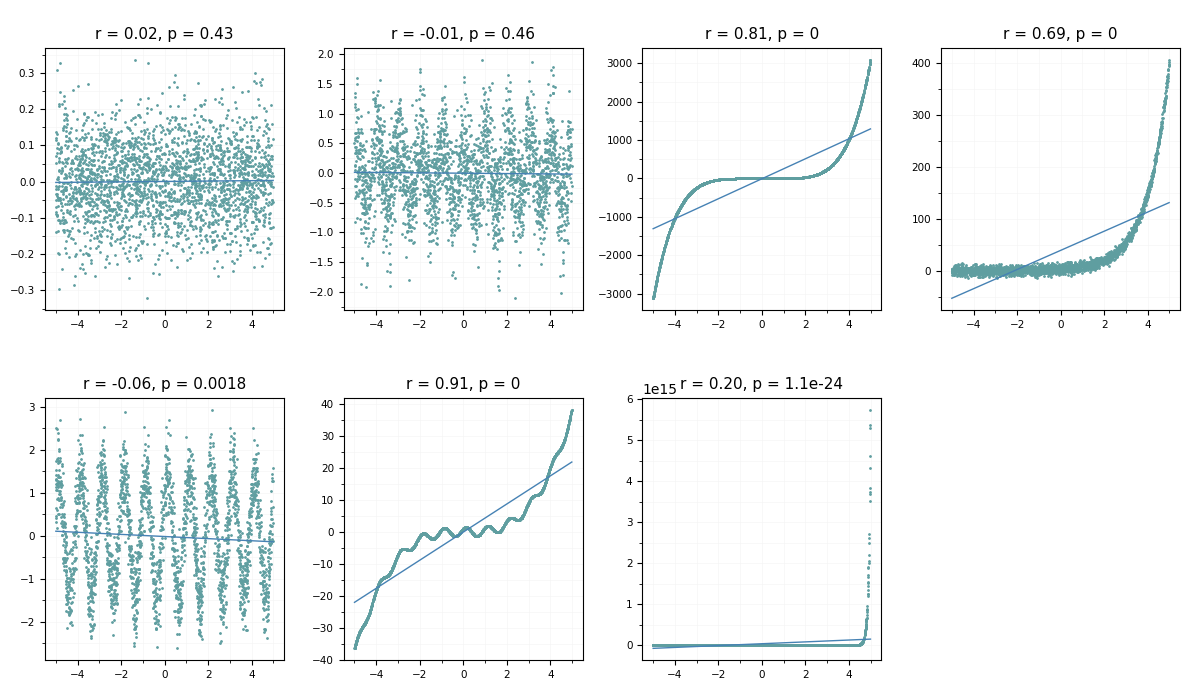

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
from scipy.stats import pearsonr
from math import pi

# note that `make_pipeline` is shorthand for `pipeline` where sklearn handles the naming for you
model = make_pipeline(PolynomialFeatures(degree=2),
                      LinearRegression())


S, C, LINECOLOR, LINEWIDTH = 2.5, "cornflowerblue", "steelblue", 1

def plot_scatter(xs, ys, nrows, ncols, figsize, titles, **kwargs):
    s, c = kwargs.get("s", S), kwargs.get("c", C)
    linecolor, linewidth = kwargs.get("linecolor", LINECOLOR), kwargs.get("linewidth", LINEWIDTH)

    rs_and_ps = [pearsonr(x, y) for x, y in zip(xs, ys)]
    rs, ps = [rp[0] for rp in rs_and_ps], [rp[1] for rp in rs_and_ps]

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    if (nrows, ncols) == (1, 1):
            axes = np.array([axes])
    for ax, title, r, p, x, y in zip(axes.flatten(), titles, rs, ps, xs, ys):
            ax.set_axisbelow(True)
            ax.xaxis.set_minor_locator(AutoMinorLocator(2))
            ax.yaxis.set_minor_locator(AutoMinorLocator(2))
            ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
            ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)

            ax.scatter(x, y, s=s, c=c, zorder=2)
            a, b = np.polyfit(x, y, 1) # fit regression line y = a*x + b
            x_line = np.linspace(x.min(), x.max(), 200)
            y_line = a * x_line + b
            ax.plot(x_line, y_line, color=linecolor, linewidth=linewidth, zorder=3)
            ax.tick_params(axis="both", which="major", labelsize=7.5)
            ax.set_title(f"{title}\nr = {r:.2f}, p = {p:.2g}", fontsize=11)

    for ax in axes.flatten()[len(titles):]:
            ax.remove()

    fig.tight_layout()
    plt.show()


# Generate synthetic data
def func(x, *, alpha=0, beta=0, gamma=0, delta=0, **kwargs):
    intercept_center, intercept_std = kwargs.get("intercept_center", 0), kwargs.get("intercept_std", 0)
    cos_shift, trig_std = kwargs.get("cos_shift", 0), kwargs.get("trig_std", 0)
    poly_shift, poly_std, poly_power = kwargs.get("poly_shift", 0), kwargs.get("poly_std", 0), kwargs.get("poly_power", 1)
    expo_shift, expo_std, expo_power = kwargs.get("expo_shift", 0), kwargs.get("expo_std", 0), kwargs.get("expo_power", 1)

    intercept = np.random.normal(loc=intercept_center, scale=intercept_std, size=x.size)
    trig = np.random.normal(loc=np.sin(2*pi*x) + np.cos(2*pi*x + cos_shift),
                             scale=trig_std, size=None)
    # np.power(a, x) means: first array elements raised to powers from second array, element-wise.
    poly = np.random.normal(loc=np.power(x + poly_shift, poly_power), # defines the center of each distribution;
                            scale=poly_std,
                            size=None) # size=None -> np.broadcast(loc, scale).size samples are drawn (in this case, shape matches loc)
    expo = np.random.normal(loc=np.exp((x + expo_shift)**expo_power),
                            scale=expo_std,
                            size=None)

    return alpha * intercept + beta * trig + gamma * poly + delta * expo


x = 10*(np.random.random(2500)-0.5) # random floats in the half-open interval [-0.5, 0.5) scaled by 10

y1 = func(x, alpha=1, intercept_std=0.1) # a near horizontal line (note the y scale)
y2 = func(x, beta=1, cos_shift=pi/3, trig_std=0.5)
y3 = func(x, gamma=1, poly_shift=0, poly_std=0.1, poly_power=5) # a near perfect x^5
y4 = func(x, delta=1, expo_shift=1, expo_std=5) # exponential funciton

sinusoid_noise = func(x, beta=1, cos_shift=0, trig_std=0.5)
polytrend_periodwiggle_noise = func(x, beta=1, gamma=0.3, poly_power=3)
some_combo = func(x, beta=1, delta=1.5, expo_shift=1, expo_std=1.5, expo_power=2)



plot_scatter([x]*7, [y1,y2,y3,y4,
                     sinusoid_noise,
                     polytrend_periodwiggle_noise,
                     some_combo,
                     ],
             2, 4, (12, 7),
            [""]*7, c="cadetblue", s=1)

In [ ]:
# multi-collinearity with higher-order terms

def linear_algebra_stuff(x, transforms):
    design_ms = [t.fit_transform(x.reshape(-1,1)) for t in transforms]
    svds = [np.linalg.svd(m.T @ m) for m in design_ms]
    singular_vals = [{"λ_max": f"{max(res[1]):.2e}", "λ_min": f"{min(res[1]):.2e}"} for res in svds]
    Gkapas = {i+1: float(round(max(res[1])/min(res[1]), 2))
                                for i, res in enumerate(svds)} # condition number = max(singular_value)/min(singular_value)
    Xkapas = {i+1: float(round(np.linalg.cond(m), 2))
                                for i, m in enumerate(design_ms)}
    return singular_vals, Gkapas, Xkapas


degrees = np.arange(1, 21)
poly_list = [PolynomialFeatures(degree=deg,
                          interaction_only=False,
                          include_bias=False,
                          order="C") for deg in degrees]
poly_with_scaler_list = [make_pipeline(poly, StandardScaler()) for poly in poly_list]


singular_vals1, Gkapas1, Xkapas1 = linear_algebra_stuff(x, poly_list)
singular_vals2, Gkapas2, Xkapas2 = linear_algebra_stuff(x, poly_with_scaler_list)

print(f"Condition numbers of the design matrix (X) and Gram matrix (X.T @ X) without standard scaling:\n")
for Xk, (d, Gk), s in zip(Xkapas1.values(), Gkapas1.items(), singular_vals1):
    print(f"     deg = {d:02d}:  κ_X = {Xk:.2e};   κ_G = {Gk:.2e};  λ = {s}")

Condition numbers of the design matrix (X) and Gram matrix (X.T @ X) without standard scaling:

     deg = 01:  κ_X = 1.00e+00;   κ_G = 1.00e+00;  λ = {'λ_max': '1.35e+03', 'λ_min': '1.35e+03'}
     deg = 02:  κ_X = 8.62e+00;   κ_G = 7.43e+01;  λ = {'λ_max': '4.56e+03', 'λ_min': '6.13e+01'}
     deg = 03:  κ_X = 6.19e+01;   κ_G = 3.83e+03;  λ = {'λ_max': '1.39e+04', 'λ_min': '3.62e+00'}
     deg = 04:  κ_X = 4.22e+02;   κ_G = 1.78e+05;  λ = {'λ_max': '4.34e+04', 'λ_min': '2.44e-01'}
     deg = 05:  κ_X = 2.94e+03;   κ_G = 8.64e+06;  λ = {'λ_max': '1.42e+05', 'λ_min': '1.64e-02'}
     deg = 06:  κ_X = 1.99e+04;   κ_G = 3.96e+08;  λ = {'λ_max': '4.78e+05', 'λ_min': '1.21e-03'}
     deg = 07:  κ_X = 1.40e+05;   κ_G = 1.96e+10;  λ = {'λ_max': '1.65e+06', 'λ_min': '8.44e-05'}
     deg = 08:  κ_X = 9.65e+05;   κ_G = 9.31e+11;  λ = {'λ_max': '5.82e+06', 'λ_min': '6.26e-06'}
     deg = 09:  κ_X = 6.80e+06;   κ_G = 4.62e+13;  λ = {'λ_max': '2.08e+07', 'λ_min': '4.50e-07'}
     deg = 10:  κ_X = 

In [ ]:
# Mathmatically, κ(X.T @ X) = κ(X)^2 for the condition number, assumming X has full column rank.
# In our printed results, this relationship holds up till till degree 11, after which numerical descrepancies appear.
# This is not failure pf the mathematical identity (math never lies 😇), but a consequence of the Gram matrix
# becoming extremely ill-conditioned, so machine/floating point precision (which is finite) makes tiny values representation unreliable.

print(f"Condition numbers of the design matrix (X) and Gram matrix (X.T @ X) without standard scaling:\n")
for Xk, (d, Gk), s in zip(Xkapas2.values(), Gkapas2.items(), singular_vals2):
    print(f"     deg = {d:02d}:  κ_X = {Xk:.2e};   κ_G = {Gk:.2e};  λ = {s}")

Condition numbers of the design matrix (X) and Gram matrix (X.T @ X) without standard scaling:

     deg = 01:  κ_X = 1.00e+00;   κ_G = 1.00e+00;  λ = {'λ_max': '1.00e+03', 'λ_min': '1.00e+03'}
     deg = 02:  κ_X = 7.88e+00;   κ_G = 6.21e+01;  λ = {'λ_max': '1.97e+03', 'λ_min': '3.17e+01'}
     deg = 03:  κ_X = 5.23e+01;   κ_G = 2.73e+03;  λ = {'λ_max': '2.91e+03', 'λ_min': '1.07e+00'}
     deg = 04:  κ_X = 3.16e+02;   κ_G = 1.00e+05;  λ = {'λ_max': '3.85e+03', 'λ_min': '3.85e-02'}
     deg = 05:  κ_X = 1.89e+03;   κ_G = 3.58e+06;  λ = {'λ_max': '4.77e+03', 'λ_min': '1.33e-03'}
     deg = 06:  κ_X = 1.08e+04;   κ_G = 1.17e+08;  λ = {'λ_max': '5.69e+03', 'λ_min': '4.84e-05'}
     deg = 07:  κ_X = 6.42e+04;   κ_G = 4.12e+09;  λ = {'λ_max': '6.60e+03', 'λ_min': '1.60e-06'}
     deg = 08:  κ_X = 3.70e+05;   κ_G = 1.37e+11;  λ = {'λ_max': '7.51e+03', 'λ_min': '5.50e-08'}
     deg = 09:  κ_X = 2.16e+06;   κ_G = 4.65e+12;  λ = {'λ_max': '8.41e+03', 'λ_min': '1.81e-09'}
     deg = 10:  κ_X = 

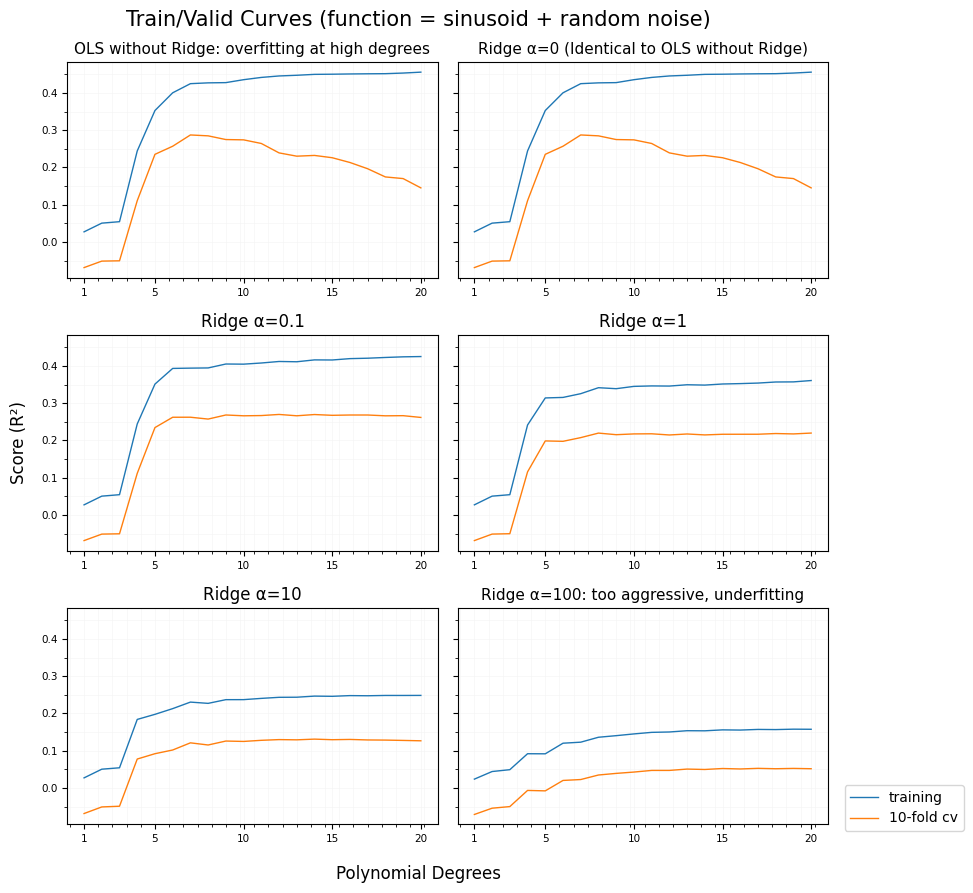

In [ ]:
# Fit polynomials of increasing degrees:
from sklearn.model_selection import validation_curve
from sklearn.linear_model import Ridge

# reducing sample size down to 200 to make overfitting at high degrees look more dramatic
x = 2*(np.random.random(200)-0.5)
target = func(x, beta=1, cos_shift=0, trig_std=1.25)

alphas = [0, 0.1, 1, 10, 100]
ols = make_pipeline(PolynomialFeatures(), StandardScaler(), LinearRegression())
ols_ridges = [make_pipeline(PolynomialFeatures(), StandardScaler(), Ridge(alpha=a))
                                for a in alphas]
models = [ols] + ols_ridges

degrees = np.arange(1, 21)
results = [validation_curve(model, x.reshape(-1, 1), target,
                            cv=10,
                            param_name="polynomialfeatures__degree",
                            param_range=degrees)
                        for model in models]
train_scores = [res[0].mean(axis=1) for res in results]
valid_scores = [res[1].mean(axis=1) for res in results]

fig, axes = plt.subplots(3, 2, figsize=(8.5, 9), sharey=True)
for ax, t, v, a in zip(axes.flatten(), train_scores, valid_scores, [None]+alphas):
    ax.plot(degrees, t, label="training", linewidth=1, zorder=3)
    ax.plot(degrees, v, label="10-fold cv", linewidth=1, zorder=2)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
    ax.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.tick_params(axis="both", which="major", labelsize=7.5)
    if a is not None:
        if a == 0:
            ax.set_title(f"Ridge α={a} (Identical to OLS without Ridge)", fontsize=11)
        elif a == 100:
            ax.set_title(f"Ridge α={a}: too aggressive, underfitting", fontsize=11)
        else:
            ax.set_title(f"Ridge α={a}")
    else:
        ax.set_title(f"OLS without Ridge: overfitting at high degrees", fontsize=11)


handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(1.15, 0.06))
fig.supxlabel("Polynomial Degrees", fontsize=12)
fig.supylabel("Score (R²)", fontsize=12)
fig.suptitle("Train/Valid Curves (function = sinusoid + random noise)", fontsize=15);
fig.tight_layout()
plt.show()